Face emotion recognation --deep learning project


In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [3]:
!kaggle datasets download -d msambare/fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
fer2013.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
# unzip the data
import zipfile
import os

zip_file_path = '/content/fer2013.zip'


zip_ref = zipfile.ZipFile(zip_file_path,'r')
zip_ref.extractall('/content')
zip_ref.close()
print(f"Successfully unzipped '{zip_file_path}' to '/content'.")

Successfully unzipped '/content/fer2013.zip' to '/content'.


In [ ]:
train = '/content/train'
test = '/content/test'

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
# Initialize ImageDataGenerators for data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Prepare iterators for training and validation datasets
training_set = train_datagen.flow_from_directory(
    train,
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical'
)

test_set = test_datagen.flow_from_directory(
    test,
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical'
)

print("Image data generators have been set up.")

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Image data generators have been set up.


In [ ]:
# Build the CNN model
model = Sequential([
    tf.keras.layers.Input(shape=(48, 48, 1)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    Dropout(0.5),

    Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    Dropout(0.5),

    Dense(7, activation='softmax') # 7 classes for emotions
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("CNN model defined and compiled.")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 692,359 (2.64 MB)

 Trainable params: 691,975 (2.64 MB)

 Non-trainable params: 384 (1.50 KB)

CNN model defined and compiled.


In [ ]:
# Train the model
history = model.fit(
    training_set,
    steps_per_epoch=training_set.samples // training_set.batch_size,
    epochs=50,
    validation_data=test_set,
    validation_steps=test_set.samples // test_set.batch_size
)

print("Model training complete.")

Epoch 1/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.1899 - loss: 2.2615 - val_accuracy: 0.2518 - val_loss: 1.8063
Epoch 2/50
  1/448 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.2344 - loss: 1.9817

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2344 - loss: 1.9817 - val_accuracy: 0.2524 - val_loss: 1.8064
Epoch 3/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 27s 59ms/step - accuracy: 0.2327 - loss: 1.8639 - val_accuracy: 0.1740 - val_loss: 3.8030
Epoch 4/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1562 - loss: 1.8998 - val_accuracy: 0.1738 - val_loss: 4.0138
Epoch 5/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.2581 - loss: 1.7890 - val_accuracy: 0.2390 - val_loss: 1.7479
Epoch 6/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2500 - loss: 1.7659 - val_accuracy: 0.2411 - val_loss: 1.7459
Epoch 7/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 27s 59ms/step - accuracy: 0.3001 - loss: 1.7064 - val_accuracy: 0.3456 - val_loss: 1.6346
Epoch 8/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2812 - loss: 1.7185 - val_accuracy: 0.3470 - val_loss: 1.6336
Epoch 9/50
448/448 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.3256 - loss: 1.6681 - val_accuracy: 0.381

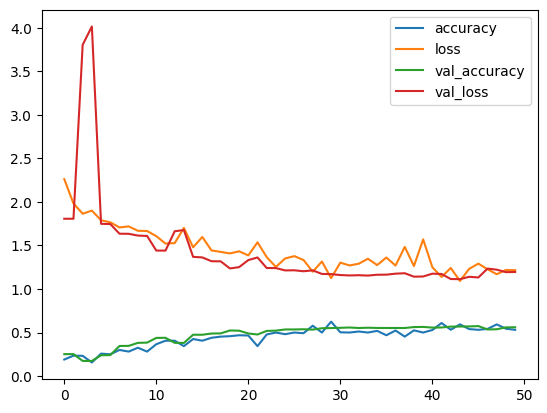

In [ ]:
import matplotlib.pyplot as plt

for key in history.history.keys():
    plt.plot(history.history[key], label=key)
plt.legend()

lets try for mask it is easy task so lets get into it


In [4]:
!kaggle datasets download -d shiekhburhan/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/shiekhburhan/face-mask-dataset
License(s): CC0-1.0
100% 2.33G/2.33G [00:31<00:00, 79.9MB/s]



In [1]:
# unzip the data
import zipfile
import os

zip_file_path = '/content/face-mask-dataset.zip'


zip_ref = zipfile.ZipFile(zip_file_path,'r')
zip_ref.extractall('/content')
zip_ref.close()
print(f"Successfully unzipped '{zip_file_path}' to '/content'.")

Successfully unzipped '/content/face-mask-dataset.zip' to '/content'.


In [17]:
import cv2
import os

# Define base paths
simple_path = '/content/FMD_DATASET/with_mask/simple'

images = []
labels = []

def load_images_from_folder(folder, label_value):
    for filename in os.listdir(folder):

        img_path = os.path.join(folder, filename)

        img = cv2.imread(img_path)

        if img is not None:
            images.append(img)
            labels.append(label_value)

load_images_from_folder(simple_path, 1)

print(f"Total images loaded: {len(images)}")

Total images loaded: 4000


In [6]:
# Define base paths
simple_path = '/content/FMD_DATASET/without_mask/simple'

images = []
labels = []

def load_images_from_folder(folder, label_value):
    for filename in os.listdir(folder):

        img_path = os.path.join(folder, filename)

        img = cv2.imread(img_path)

        if img is not None:
            images.append(img)
            labels.append(label_value)

load_images_from_folder(simple_path, 0)

print(f"Total images loaded: {len(images)}")

Total images loaded: 4000


In [49]:
final_df = pd.DataFrame({'image': images, 'label': labels})

In [ ]:
final_df

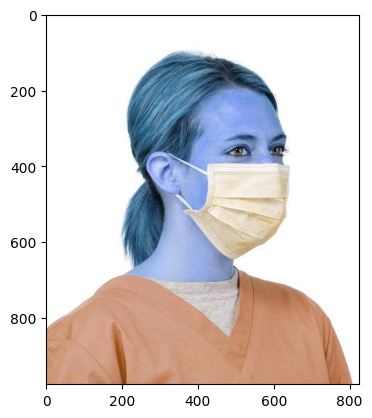

In [38]:
import matplotlib.pyplot as plt
plt.imshow(images[0])

In [33]:
labels[0]

1